# 13. Turning the knobs

[Notebook 6](06_combining_and_sensitivity.ipynb) says a result is only as firm as its
assumptions. This one **turns each knob and measures what moves**, on terrain small
enough that every cell runs in seconds.

The magnitudes here are not the ones to quote — synthetic terrain is not Peru, and the
real numbers are in notebooks 9 to 12. What transfers is the **shape** of each response:
which knobs are gentle, which sit on cliffs, and which change one reported number while
leaving another alone.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import contextlib
import io
import time

from oroscope import arrival_scan, scoring
from oroscope import site_searcher as ss
from scipy.ndimage import binary_closing, label

## A canyon to work on

Built in place rather than imported, so this notebook runs on a bare clone. Colca's
published geometry: ~1.5 km deep, ~4.5 km rim to rim, which implies ~40.6° walls.

700 x 700 px, pixel 30.7 x 29.8 m
elevation 2,000 - 3,780 m


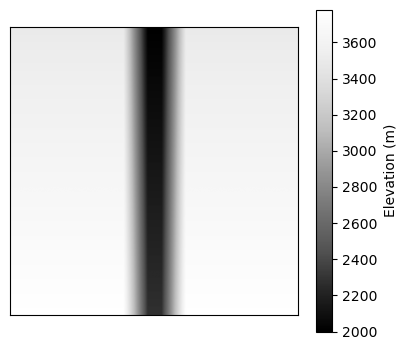

In [2]:
CELL_DEG = 1 / 3600.0
grid = ss.resolve_grid_geometry("no-such-file.tif", -15.6, cell_size_deg=CELL_DEG)

n = 700
cols = np.arange(n, dtype=np.float64)[None, :].repeat(n, 0)
x = cols * grid.cell_size_x
centre = (n * grid.cell_size_x) / 2.0
from_edge = np.abs(x - centre) - 500.0                 # 1 km floor
rise = np.clip(from_edge, 0.0, None) * np.tan(np.radians(40.6))
z = (3500.0 - 1500.0 + np.clip(rise, 0.0, 1500.0)).astype(np.float32)
# A gentle along-axis tilt, so the canyon is not perfectly translation-invariant
z = z + (np.arange(n, dtype=np.float32)[:, None] * 0.4)

print(f"{n} x {n} px, pixel {grid.cell_size_y:.1f} x {grid.cell_size_x:.1f} m")
print(f"elevation {z.min():,.0f} - {z.max():,.0f} m")

plt.figure(figsize=(4.2, 3.6))
plt.imshow(z, cmap="Greys_r")
plt.colorbar(label="Elevation (m)")
plt.xticks([])
plt.yticks([])
plt.tight_layout()

## The funnel, live

Every run records how many pixels survived each stage. This is the same table
`--explain` prints, on this canyon, for TAMBO's criteria.

In [3]:
TAMBO = dict(min_slope_deg=20.0, max_slope_deg=60.0,
             min_dist_km=2.0, max_dist_km=5.0,
             elev_min_deg=-20.0, elev_max_deg=20.0, n_elev_bins=20,
             n_azimuths=9, half_width_deg=60.0,
             min_target_slope_deg=25.0, max_range_m=5000.0)


def screen(stride):
    """Stage 1 and 2: the slope band, then striding.

    The screen's progress bar goes to stderr, where a notebook stores it as output. It
    reports a step that takes a fraction of a second here, so it is carrying nothing.
    """
    with contextlib.redirect_stderr(io.StringIO()):
        return ss.get_candidates_chunked(
            z, grid, None, -15.6, -72.4,
            min_slope_deg=TAMBO["min_slope_deg"],
            max_slope_deg=TAMBO["max_slope_deg"], candidate_stride=stride)


def scan(cand, **over):
    """Stage 3: the arrival scan."""
    kw = {k: v for k, v in TAMBO.items()
          if k not in ("min_slope_deg", "max_slope_deg")}
    kw.update(over)
    return arrival_scan.scan(cand, z, grid, **kw)


cand = screen(1)
obs = scan(cand)
accepted = int((obs["cells"] > 0).sum())
print(f"{'DEM pixels':<28}{z.size:>12,}")
print(f"{'slope 20-60 deg, stride 1':<28}{len(cand):>12,}"
      f"   {100*len(cand)/z.size:5.1f}% of the DEM")
print(f"{'directions accepted':<28}{accepted:>12,}"
      f"   {100*accepted/len(cand):5.1f}% of candidates")

DEM pixels                       490,000
slope 20-60 deg, stride 1         82,600    16.9% of the DEM
directions accepted               82,600   100.0% of candidates


---

## Knob 1: `candidate_stride`

Keeps one surviving pixel in N. **Cost control, not a criterion** — so the thing to
check is whether it biases the answer. Acceptance says no.

In [4]:
print(f"{'stride':>7}{'candidates':>13}{'accepted':>11}{'acceptance':>13}{'scan time':>12}")
for stride in (1, 2, 5, 10):
    c = screen(stride)
    t = time.perf_counter()
    o = scan(c)
    dt = time.perf_counter() - t
    a = int((o["cells"] > 0).sum())
    print(f"{stride:>7}{len(c):>13,}{a:>11,}{100*a/len(c):>12.1f}%{dt:>11.2f}s")

 stride   candidates   accepted   acceptance   scan time


      1       82,600     82,600       100.0%       0.37s


      2       41,300     41,300       100.0%       0.17s


      5       16,520     16,520       100.0%       0.09s


     10        8,260      8,260       100.0%       0.04s


**Acceptance barely moves; the cost falls as 1/N.** That is the whole case for
striding, and it is why the funnel labels it "not a constraint".

The catch is not here. It is that striding leaves a **gap**, and what happens to that gap
decides the reported area.

## Knob 2: `gap_close_km`, and why the penalty depends on how thin the ground is

Striding leaves a gap. Closing repairs it — but how *well* depends on something the
parameter does not mention: **the width of the accepted feature**. A wide blob survives a
marginal element; a narrow strip does not.

That is the difference between a 4.75× under-report at Colca and a 291× one on the
Callejón de Huaylas, and it is worth seeing on its own, so here it is on synthetic
strips of controlled width rather than on the canyon above.

In [5]:
def recovery(width_px, stride=5, elements=(3, 5, 9)):
    """How much of a strip of a given width survives striding and closing."""
    m = 400
    rr, cc = np.mgrid[0:m, 0:m]
    truth = np.abs(cc - 200 - 40 * np.sin(rr / 50.0)) < width_px / 2
    strided = np.zeros_like(truth)
    strided[::stride, ::stride] = truth[::stride, ::stride]
    out = {}
    for k in elements:
        closed = binary_closing(strided, np.ones((k, k)))
        out[k] = (closed.sum() / truth.sum(), label(closed)[1])
    return out


print("Fraction of the accepted strip recovered, after stride 5 and closing:")
print(f"{'strip width':>12}{'element 3 px':>14}{'element 5 px':>14}{'element 9 px':>14}")
for width in (3, 6, 12, 30, 80):
    r = recovery(width)
    print(f"{width:>10} px" + "".join(f"{r[k][0]:>13.2f}x" for k in (3, 5, 9)))

Fraction of the accepted strip recovered, after stride 5 and closing:
 strip width  element 3 px  element 5 px  element 9 px
         3 px         0.04x         0.10x         0.10x
         6 px         0.04x         0.16x         0.16x


        12 px         0.04x         0.51x         0.51x
        30 px         0.04x         0.79x         0.79x
        80 px         0.04x         0.91x         0.91x


Two things, and the second is the one that is easy to miss.

**An element below the gap never recovers anything** — 0.04× at every width, because the
marks simply never touch. That is the failure the warning catches.

**An element at or above the gap recovers a fraction that depends on the width.** At 5 px
against a 5 px gap: 0.10× for a 3-pixel strip, 0.91× for an 80-pixel one. So "the element
outruns the gap" is necessary and **not sufficient**. A canyon wall a few pixels across
loses most of itself to a nominally adequate element, and that is exactly the terrain
TAMBO selects.

And the loss does not show up where you would look for it — in the area — but in the
**region count**, because pruning then discards what fragmented:

In [6]:
print(f"{'strip width':>12}{'regions after closing at 5 px':>32}")
for width in (3, 6, 12, 30, 80):
    print(f"{width:>10} px{recovery(width)[5][1]:>32,}")

 strip width   regions after closing at 5 px
         3 px                              36


         6 px                              24
        12 px                               1
        30 px                               1


        80 px                               1


A strip that should be one region becomes dozens or hundreds, and
`min_sub_array_size` then throws away every piece too small to hold an array. **That is
where the factor of 291 went** — not into the area measurement.

The warning that fires on the first condition:

In [7]:
for stride in (1, 5, 15):
    verdict = ss.warn_stride_outruns_closing(stride, grid.cell_size_y,
                                             gap_close_km=0.1,      # TAMBO's 100 m
                                             antenna_spacing_km=0.1, quiet=True)
    gap = ss.stride_gap_m(stride, grid.cell_size_y)
    state = "ok" if verdict is None else f"WARNS, {verdict['ratio']:.2f}x short"
    print(f"stride {stride:>2}: gap {gap:>6.0f} m against a 100 m element -> {state}")

stride  1: gap     31 m against a 100 m element -> ok
stride  5: gap    154 m against a 100 m element -> WARNS, 1.54x short
stride 15: gap    461 m against a 100 m element -> WARNS, 4.61x short


---

## Knob 3: `min_score`, the dominant assumption

In [8]:
cfg = dict(solid_angle_half_sr=0.8, grammage_mode="particle",
           grammage_band_gcm2=(236.0, 1287.0), shower_development_m=0.0,
           decay_energy_min_pev=3.0, decay_energy_max_pev=1000.0,
           decay_spectral_index=2.0, composition="product")
obs["altitude_m"] = z[cand[:, 0].astype(int), cand[:, 1].astype(int)].astype(float)
total, parts = scoring.score_candidates(obs, cfg, distance_window_m=(2000.0, 5000.0))
viable = obs["cells"] > 0

print(f"components: {', '.join(parts)}")
print(f"viable candidates: {viable.sum():,}")
print()
print(f"{'min_score':>10}{'kept':>10}{'of viable':>12}")
for cut in (0.0, 0.1, 0.2, 0.35, 0.5, 0.7):
    kept = int((total[viable] >= cut).sum())
    print(f"{cut:>10.2f}{kept:>10,}{100*kept/viable.sum():>11.1f}%")

components: depth, solid_angle, distance, shower, decay
viable candidates: 82,600

 min_score      kept   of viable
      0.00    82,600      100.0%
      0.10    82,600      100.0%
      0.20    82,072       99.4%
      0.35    77,588       93.9%
      0.50    71,448       86.5%
      0.70    12,488       15.1%


On this terrain the fall is gentle until 0.5 and then steep — but **where the
steep part sits is not a property of the terrain**. It moves when a component is added,
because a product of numbers in [0, 1] concentrates near zero and every extra factor
pushes the whole population down. On the real Colca run the same cut at 0.0, 0.35 and 0.5
gave 45,928, 2,056 and **zero** detector positions.

`score_percentile` asks for a rank instead, which is scale-free. It is not the default
only because every published number here used `min_score`.

## Knob 4: `min_target_slope_deg`, which describes the far wall

In [9]:
print(f"{'min_target_slope':>18}{'accepted':>11}{'of candidates':>15}")
for floor in (None, 15.0, 25.0, 35.0, 38.0, 42.0, 45.0):
    o = scan(cand, min_target_slope_deg=floor)
    a = int((o["cells"] > 0).sum())
    label_ = "unset" if floor is None else f"{floor:.0f} deg"
    print(f"{label_:>18}{a:>11,}{100*a/len(cand):>14.1f}%")

  min_target_slope   accepted  of candidates


             unset     82,600         100.0%


            15 deg     82,600         100.0%


            25 deg     82,600         100.0%


            35 deg     82,600         100.0%


            38 deg     78,436          95.0%


            42 deg          0           0.0%


            45 deg          0           0.0%


These walls were built at 40.6°, and the criterion finds them: everything below
that passes, everything above fails, with the step in between. On real terrain the wall
slopes are a *distribution* rather than one value, so the step becomes a slope — and it
sits further right than the median, because the criterion is applied per direction while
the reported `target_slope_deg` is a mean over each candidate's accepted directions. See
[notebook 10](10_ancash_dem.ipynb).

The important point is that this is the **far** wall, the one the tau exits.
`min_slope_deg`/`max_slope_deg` describe the **near** ground the array stands on. A single
slope band cannot express both, which is why there are two.

## Knob 5: `downsample_factor`, which moves one number and not the other

In [10]:
def accepted_mask(stride=1, element_px=3):
    """The accepted set at a stride, closed with an element of a given size."""
    c = screen(stride)
    o = scan(c)
    ok = o["cells"] > 0
    mask = np.zeros(z.shape, dtype=bool)
    mask[c[ok, 0].astype(int), c[ok, 1].astype(int)] = True
    return binary_closing(mask, np.ones((element_px, element_px)))


m = accepted_mask()
px_km2 = grid.cell_size_y * grid.cell_size_x / 1e6
full_km2 = m.sum() * px_km2
cap = ss.count_grid_capacity(np.ascontiguousarray(m), grid.cell_size_y,
                             grid.cell_size_x, 100.0, 1)
print(f"{'downsample':>11}{'area km2':>11}{'vs full':>9}{'capacity':>11}")
for ds in (1, 2, 4, 8):
    area = m[::ds, ::ds].sum() * px_km2 * ds * ds
    print(f"{ds:>11}{area:>11.2f}{area/full_km2:>8.2f}x{cap:>11,}")

 downsample   area km2  vs full   capacity
          1      75.36    1.00x      8,645
          2      74.09    0.98x      8,645
          4      76.42    1.01x      8,645
          8      76.42    1.01x      8,645


**Area is measured on the downsampled mask; capacity is counted at full
resolution.** On a feature this wide the area survives downsampling almost exactly — which
is the honest result here, and worth stating, because the ~30% loss quoted for real canyon
strips is a statement about *thin* features and about the interaction with pruning, not
about subsampling arithmetic.

The trap is the one that survives regardless: **the ratio of capacity to area is not a
property of the terrain**, because the two were measured on different grids. And
`candidate_stride` is the memory lever, not this one — candidates are taken on the native
grid, so downsampling scales the labelling arrays as its inverse square and barely touches
the dominant term.

---

## What to take away

| Knob | Response | Watch for |
| --- | --- | --- |
| `candidate_stride` | acceptance flat, cost 1/N | the gap it leaves |
| `gap_close_km` | **cliff at the stride gap** | areas collapsing, region counts exploding |
| `min_score` | **cliff**, moving with component count | prefer `score_percentile` |
| `min_target_slope_deg` | sharp at the true wall slope | it is the *far* wall, not the near one |
| `downsample_factor` | area falls, capacity does not | comparing the two across grids |

Two of the five sit on cliffs, and a third moves one reported number without moving
another. **Read this notebook before quoting any single number from a run** — and read
[notebook 6](06_combining_and_sensitivity.ipynb) for what a sensitivity sweep does with
the whole pipeline rather than one stage.

## Where to go next

- **[7. Animating the mechanism](07_animating_the_mechanism.ipynb)** — several of the
  responses above, as films.
- **[6. Combining and sensitivity](06_combining_and_sensitivity.ipynb)** — sweeps over
  the whole pipeline.
- **[10. Ancash](10_ancash_dem.ipynb)** — where the striding cliff was measured at 291×
  on real ground.

---

*Part of the [Oroscope](https://github.com/mbustama/oroscope) tutorials. Previous: [Peru, all of it](12_peru_dem.ipynb). Full API reference: [oroscope docs](https://mbustama.github.io/oroscope/functions.html).*